In [1]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

In [2]:
model = joblib.load('model/model_ann.joblib')
model

MLPClassifier(activation='tanh', alpha=0.0003, early_stopping=True,
              learning_rate_init=0.0005, max_iter=800, n_iter_no_change=30,
              random_state=1, verbose=True)

In [3]:
data_test = pd.read_csv('./data/features.test.csv').set_index('id')


In [4]:
X_test = data_test.drop(columns='label')
y_test = data_test['label']

In [5]:
result = permutation_importance(
    model, X_test, y_test,
    n_repeats = 10,        
    random_state = 0,
    n_jobs = -1            
)

In [6]:
importance_ann = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

/tmp/ipykernel_3601/3148537873.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


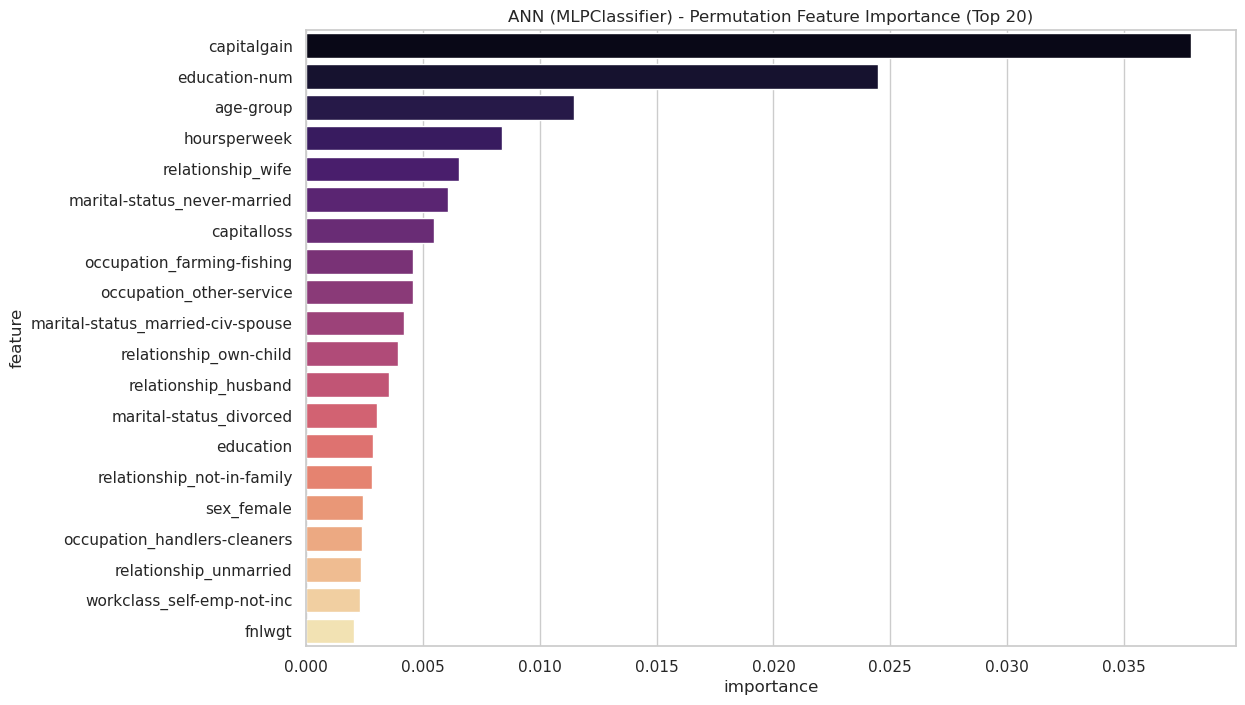

In [7]:
sns.set(style='whitegrid', rc={'figure.figsize': (12, 8)})
sns.barplot(
    x = 'importance',
    y = 'feature',
    data = importance_ann.head(20),
    palette = 'magma'
)
plt.title("ANN (MLPClassifier) - Permutation Feature Importance (Top 20)")
plt.show()

In [8]:
importance_ann.to_csv('./results/feature_importance_ann.csv', index=False)